# Baseline ML 

Este notebook replica el flujo simple del reel (cargar datos → features → split temporal → entrenar → evaluar):
- Datos desde `DataCleaner`/`preprocess_data`.
- Target **direction_2h** (0=DOWN, 1=FLAT, 2=UP).
- Split temporal + `TimeSeriesSplit` para selección de features.

> **Nota seguridad:** no hardcodear claves API en el repo. Usa variables de entorno.


In [1]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data


In [2]:
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol=["QQQ", "TLT", "VXX", "BNDX"],
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()
df = preprocess_data(df_raw, "qqq")

df.head()


c:\Users\jorge\OneDrive\Escritorio\TRADING_ALG\src\data_cleaner.py:242: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["return"] = df["close"].pct_change()


,datetime,open_bndx,open_qqq,open_tlt,open_vxx,high_bndx,high_qqq,high_tlt,high_vxx,low_bndx,...,log_return_lag5,vol_rolling,rsi,macd,macd_signal,ema_9,ema_21,ema_50,ema_100,ema_200
0,2022-01-03 14:25:00+00:00,55.06,399.38,146.55,18.2100,55.060,399.41,146.600,18.30,55.06,...,-0.000275,0.000512,21.777778,-0.000707,-0.000518,399.110000,399.110000,399.110000,399.110000,399.110000
1,2022-01-03 14:30:00+00:00,55.03,399.05,146.41,18.2700,55.060,400.68,146.500,18.29,55.01,...,0.000601,0.000921,50.991501,-0.000474,-0.000509,399.372000,399.229091,399.161373,399.135941,399.123035
2,2022-01-03 14:35:00+00:00,55.02,400.44,146.36,18.1200,55.035,401.53,146.595,18.16,55.01,...,-0.000025,0.000983,60.246913,-0.000158,-0.000439,399.709600,399.395537,399.235829,399.174041,399.142308
3,2022-01-03 14:40:00+00:00,55.03,401.07,146.57,18.0701,55.040,401.26,146.800,18.15,55.03,...,0.000326,0.001024,57.547170,-0.000008,-0.000353,399.879680,399.501397,399.287757,399.201486,399.156414
4,2022-01-03 14:45:00+00:00,55.03,400.57,146.53,18.1100,55.050,400.75,146.940,18.56,55.03,...,-0.000050,0.001669,36.489076,-0.000359,-0.000354,399.547244,399.384679,399.245786,399.182001,399.147072


In [16]:
HORIZON = 24  # 2h en velas de 5m
eps = 1e-12

# features
df["return"] = df["close"].pct_change()
df["logret"] = np.log(df["close"].clip(lower=eps)).diff()

df["volatility"] = df["return"].rolling(5).std()
df["vol_5"]  = df["logret"].rolling(5).std()
df["vol_20"] = df["logret"].rolling(20).std()

for w in [5, 10, 20, 50, 100, 200]:
    df[f"ma_{w}"] = df["close"].rolling(w).mean()
    df[f"dist_ma_{w}"] = df["close"] / (df[f"ma_{w}"] + eps) - 1

if "rsi" not in df.columns:
    n = 14
    delta = df["close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    avg_loss = loss.ewm(alpha=1/n, adjust=False, min_periods=n).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    df["rsi"] = 100 - (100 / (1 + rs))

for sym in ["tlt", "vxx", "bndx"]:
    c = f"close_{sym}"
    r = f"ret_{sym}"
    if c in df.columns:
        df[r] = df[c].pct_change()

for lag in [1, 3, 6, 12]:
    df[f"return_lag{lag}"] = df["return"].shift(lag)
    df[f"rsi_lag{lag}"]    = df["rsi"].shift(lag)

# --- target ---
df["close_future"] = df["close"].shift(-HORIZON)
df["direction_2h"] = (df["close_future"] > df["close"]).astype(int)

df = df.dropna().reset_index(drop=True)


In [17]:
features = [
    "close","volume","return","logret","vol_5","vol_20",
    "ma_5","ma_10","ma_20","ma_50","ma_100","ma_200",
    "dist_ma_5","dist_ma_10","dist_ma_20","dist_ma_50","dist_ma_100","dist_ma_200",
    "ret_tlt","ret_vxx","ret_bndx",
    "rsi","return_lag1","return_lag3","return_lag6","return_lag12",
    "rsi_lag1","rsi_lag3","rsi_lag6","rsi_lag12"
]

# qué features te faltan (por si algún exógeno no está)
missing = [c for c in features if c not in df.columns]
print("missing:", missing)

features_ok = [c for c in features if c in df.columns]

X = df[features_ok]
y = df["direction_2h"]

y.value_counts()


missing: []


direction_2h
1    42898
0    36546
Name: count, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [32]:
df["return"] = df["close"].pct_change(fill_method=None)

X = df.select_dtypes(include=[np.number]).drop(columns=["close_future","direction_2h"], errors="ignore")
y = df["direction_2h"].astype(int)

selected_lstm = [
    "close", "volume",
    "return", "logret", "vol_20",
    "rsi", "return_lag3", "rsi_lag6",
    "dist_ma_20", "dist_ma_50", "dist_ma_100", "dist_ma_200",
    "ret_tlt","ret_vxx","ret_bndx"
]

Xsel = X[selected_lstm]


# Split + Scaler

In [ ]:
LOOKBACK = 96
split = int(len(Xsel) * 0.8)

scaler = StandardScaler()
scaler.fit(Xsel.iloc[:split])          # fit SOLO train

X_scaled = scaler.transform(Xsel)
y_arr = y.to_numpy().astype(int)


# Secuencias para la LSTM

In [37]:
Xs, ys, idxs = [], [], []

for i in range(LOOKBACK, len(X_scaled)):
    Xs.append(X_scaled[i-LOOKBACK:i])
    ys.append(y_arr[i])
    idxs.append(i)

Xs = np.array(Xs)
ys = np.array(ys)
idxs = np.array(idxs)

train_mask = idxs < split
X_train, y_train = Xs[train_mask], ys[train_mask]
X_test,  y_test  = Xs[~train_mask], ys[~train_mask]

print(X_train.shape, X_test.shape)


(63459, 96, 15) (15889, 96, 15)


In [38]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

# val = último 10% del train (sin shuffle)
cut = int(len(X_train) * 0.9)
X_tr, y_tr = X_train[:cut], y_train[:cut]
X_val, y_val = X_train[cut:], y_train[cut:]

model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, X_train.shape[2])),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

es = EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)


c:\Users\jorge\OneDrive\Escritorio\ENTORNOS VIRTUALES\VENV_ML\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[es],
    verbose=1
)

model.evaluate(X_test, y_test, verbose=1)


Epoch 1/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 42s 182ms/step - accuracy: 0.5356 - auc: 0.4218 - loss: nan - val_accuracy: 0.4694 - val_auc: 0.0000e+00 - val_loss: nan
Epoch 2/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.4659 - auc: 0.0000e+00 - loss: nan - val_accuracy: 0.4694 - val_auc: 0.0000e+00 - val_loss: nan
Epoch 3/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 39s 175ms/step - accuracy: 0.4659 - auc: 0.0000e+00 - loss: nan - val_accuracy: 0.4694 - val_auc: 0.0000e+00 - val_loss: nan
Epoch 4/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 38s 169ms/step - accuracy: 0.4659 - auc: 0.0000e+00 - loss: nan - val_accuracy: 0.4694 - val_auc: 0.0000e+00 - val_loss: nan
Epoch 5/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 34s 150ms/step - accuracy: 0.4659 - auc: 0.0000e+00 - loss: nan - val_accuracy: 0.4694 - val_auc: 0.0000e+00 - val_loss: nan
Epoch 6/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 33s 147ms/step - accuracy: 0.4659 - auc: 0.0000e+00 - loss: nan - val_accuracy: 0.4694 - val_auc: 0.0000e+00 - val_loss: nan
497/497 ━━━━━━

[nan, 0.4367801547050476, 0.0]

In [42]:
import numpy as np

# proba de la LSTM (sigmoid)
proba = model.predict(Xs, verbose=0).ravel()

# binario -> 1 long / 2 short
pred_dir_seq = np.where(proba >= 0.5, 1, 2)

# señal alineada a df (idxs viene del loop de secuencias)
signal = np.zeros(len(df), dtype=int)
signal[idxs] = pred_dir_seq

# backtest SOLO en test
df_bt = df.iloc[split:].copy().reset_index(drop=True)
signal_bt = signal[split:]


In [43]:
def backtest_fixed_horizon(close, signal, horizon):
    equity = np.ones(len(close))
    eq = 1.0

    in_trade = False
    entry_i = None
    exit_i = None
    entry_px = None
    side = None  # 1 long, 2 short

    long_entries = []
    short_entries = []

    for i in range(len(close)):
        # cerrar trade si toca
        if in_trade and i == exit_i:
            exit_px = close[i]
            if side == 1:   # long
                ret = exit_px / entry_px - 1
            else:           # short
                ret = entry_px / exit_px - 1
            eq *= (1 + ret)
            in_trade = False

        equity[i] = eq

        # abrir trade si no hay trade abierto
        if (not in_trade) and (signal[i] in (1, 2)) and (i + horizon < len(close)):
            in_trade = True
            entry_i = i
            exit_i = i + horizon
            entry_px = close[i]
            side = signal[i]

            if side == 1:
                long_entries.append(i)
            else:
                short_entries.append(i)

    return equity, np.array(long_entries), np.array(short_entries)

close_bt = df_bt["close"].to_numpy()
equity, long_i, short_i = backtest_fixed_horizon(close_bt, signal_bt, HORIZON)


IndexError: arrays used as indices must be of integer (or boolean) type

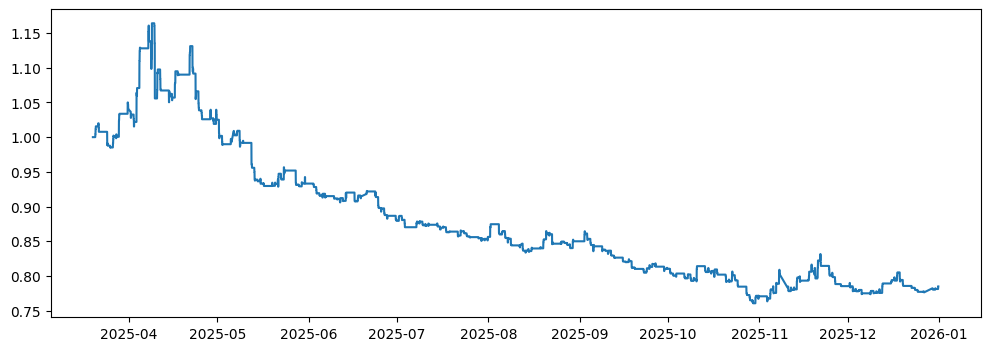

In [44]:
import matplotlib.pyplot as plt

t = df_bt["datetime"] if "datetime" in df_bt.columns else np.arange(len(df_bt))

plt.figure(figsize=(12,4))
plt.plot(t, equity, label="Equity")
plt.scatter(t[long_i],  equity[long_i],  marker="^", label="Long")
plt.scatter(t[short_i], equity[short_i], marker="v", label="Short")
plt.legend()
plt.tight_layout()
plt.show()
